================================ Human Message =================================

今天北京天气怎么样?
================================== Ai Message ==================================

我来帮您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_00_1tPQvF399odW94AZhIac1935)
 Call ID: call_00_1tPQvF399odW94AZhIac1935
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

北京今天的天气不错哦！☀️ 今天的天气状况良好，适合外出活动。不过关于更具体的温度、风力等信息，我这里暂时没有获取到详细数据。

如果您需要更详细的天气信息（比如温度范围、空气质量等），可以换个天气查询服务，或者告诉我您还需要了解哪些方面的内容，我可以再帮您确认看看～


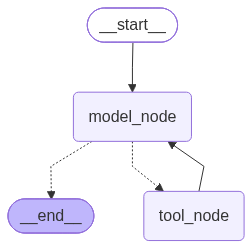

In [2]:

from typing import Literal

from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import END, START
from langgraph.graph import MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

load_dotenv(override=True)

# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    根据城市查询当日天气

    Args:
        city: 城市名称
    """
    return f"{city} 今天天气不错"


tools = [get_weather]
model_with_tools = model.bind_tools(tools=tools)


def model_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = model_with_tools.invoke(input=messages)

    return {
        "messages": [response]
    }


def router(state: MessagesState) -> Literal["tool_node", END]:
    last_msg = state["messages"][-1]

    if last_msg.tool_calls:
        return "tool_node"
    return END


builder = StateGraph(state_schema=MessagesState)
builder.add_node("model_node", model_node)
builder.add_node("tool_node", ToolNode(tools=tools))

builder.add_edge(START, "model_node")
builder.add_conditional_edges("model_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "model_node")

graph = builder.compile()

response = graph.invoke({"messages": [HumanMessage(content="今天北京天气怎么样?")]})
for msg in response["messages"]:
    msg.pretty_print()

from IPython.display import display

display(graph)